In [168]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_score, recall_score, classification_report,roc_auc_score,f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV,cross_val_predict
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [169]:
df = pd.read_csv(r"C:\Users\MADHIVANAN\Downloads\ecommerce_customers_intermediate.csv")
df.head(10)

,user_id,age,gender,country,city,device_type,traffic_source,sessions,time_spent_min,pages_visited,add_to_cart,purchase,order_value,discount_applied,customer_type
0,1,31.0,Male,USA,New York,Mobile,Organic,3,38.65,7,1,0,20.62,0,New
1,2,45.0,Male,Australia,Melbourne,Desktop,Organic,2,6.84,18,1,1,55.86,1,New
2,3,22.0,Female,Germany,Munich,Tablet,Organic,4,10.64,10,0,0,79.15,1,New
3,4,21.0,Female,USA,San Francisco,Mobile,Paid,3,17.25,21,0,0,141.62,0,New
4,5,42.0,Male,India,Chennai,Tablet,Paid,5,8.99,9,0,0,75.95,0,New
5,6,44.0,Female,India,Bangalore,Mobile,Organic,5,6.91,22,0,0,124.07,0,Returning
6,7,21.0,Female,India,Delhi,Desktop,Social,2,1.56,5,0,0,63.75,1,Returning
7,8,46.0,Male,Canada,Toronto,Mobile,Social,6,14.21,16,0,1,224.74,1,New
8,9,58.0,Male,UK,Manchester,Mobile,Social,5,19.52,13,1,1,25.79,1,New
9,10,44.0,Female,Germany,Berlin,Tablet,Referral,9,16.52,12,0,1,209.55,0,New


Features = user_id, age, gender, country, city, device_type, traffic_source, sessions, time_spent_min, pages_visited, add_to_cart, order_value, discount_applied, customer_type

Target = purchase

In [170]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           50000 non-null  int64  
 1   age               48000 non-null  float64
 2   gender            50000 non-null  object 
 3   country           50000 non-null  object 
 4   city              50000 non-null  object 
 5   device_type       50000 non-null  object 
 6   traffic_source    50000 non-null  object 
 7   sessions          50000 non-null  int64  
 8   time_spent_min    50000 non-null  float64
 9   pages_visited     50000 non-null  int64  
 10  add_to_cart       50000 non-null  int64  
 11  purchase          50000 non-null  int64  
 12  order_value       47000 non-null  float64
 13  discount_applied  50000 non-null  int64  
 14  customer_type     50000 non-null  object 
dtypes: float64(3), int64(6), object(6)
memory usage: 5.7+ MB
None


In [171]:
df.describe()

,user_id,age,sessions,time_spent_min,pages_visited,add_to_cart,purchase,order_value,discount_applied
count,50000.000000,48000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,47000.000000,50000.000000
mean,25000.500000,38.417250,3.990920,11.993590,12.504720,0.349780,0.278720,150.543979,0.301900
std,14433.901067,12.110414,1.729398,11.967093,6.924078,0.476905,0.448374,152.372554,0.459087
min,1.000000,18.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,12500.750000,28.000000,3.000000,3.460000,6.000000,0.000000,0.000000,43.220000,0.000000
50%,25000.500000,38.000000,4.000000,8.350000,13.000000,0.000000,0.000000,103.050000,0.000000
75%,37500.250000,49.000000,5.000000,16.592500,19.000000,1.000000,1.000000,207.742500,1.000000
max,50000.000000,59.000000,14.000000,129.040000,24.000000,1.000000,1.000000,1686.700000,1.000000


In [172]:
print(f"{df.isna().sum()} \n=======================================\n{df.isna().sum()/len(df)*100}")

user_id                0
age                 2000
gender                 0
country                0
city                   0
device_type            0
traffic_source         0
sessions               0
time_spent_min         0
pages_visited          0
add_to_cart            0
purchase               0
order_value         3000
discount_applied       0
customer_type          0
dtype: int64 
user_id             0.0
age                 4.0
gender              0.0
country             0.0
city                0.0
device_type         0.0
traffic_source      0.0
sessions            0.0
time_spent_min      0.0
pages_visited       0.0
add_to_cart         0.0
purchase            0.0
order_value         6.0
discount_applied    0.0
customer_type       0.0
dtype: float64


In [173]:
df.duplicated().sum()

np.int64(0)

purchase
0    36064
1    13936
Name: count, dtype: int64


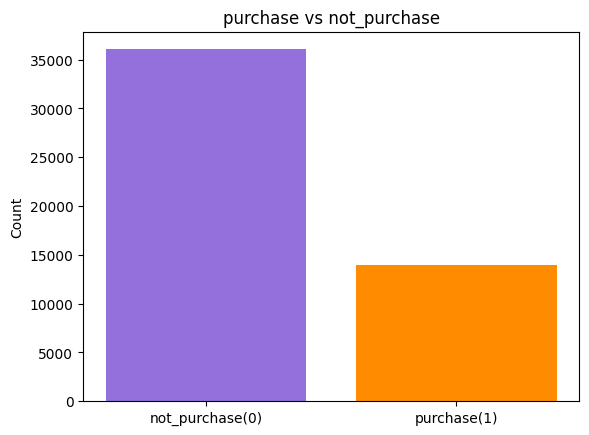

In [174]:
print(df['purchase'].value_counts()) # imbalanced
label = ['not_purchase(0)', 'purchase(1)']
purchase_count = [36064, 13936]
plt.bar(label, purchase_count, color= ["mediumpurple", "darkorange"])
plt.ylabel("Count")
plt.title("purchase vs not_purchase")
plt.show()

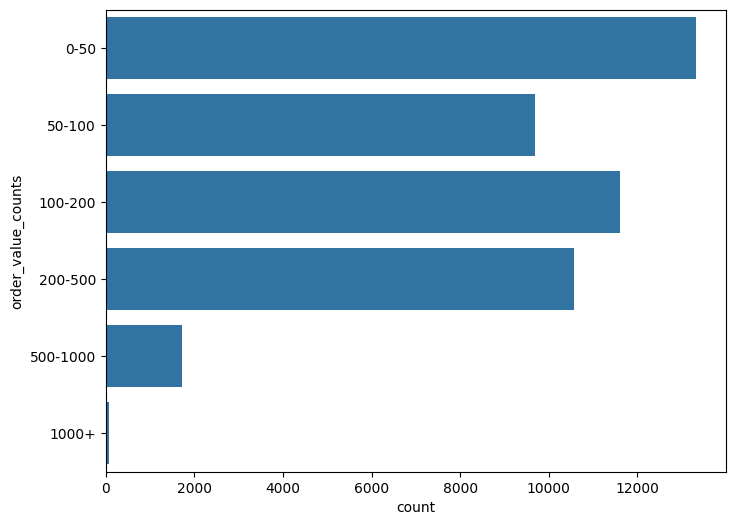

In [175]:
bins = [0, 50, 100, 200, 500, 1000, 1700]
labels = ['0-50','50-100','100-200','200-500','500-1000','1000+']
df['order_value_counts'] = pd.cut(df['order_value'],labels=labels, bins=bins)
df['order_value_counts'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.countplot(data=df['order_value_counts'])
plt.show()

age_group
30-40    11651
20-30    11484
40-50    11259
50-60    10178
18-20     2254
Name: count, dtype: int64


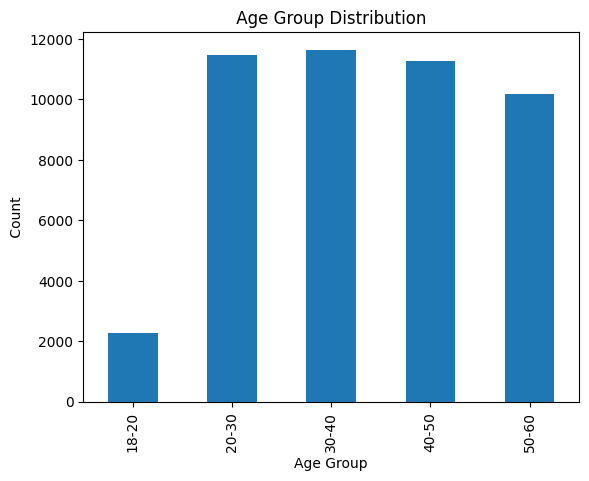

In [176]:
bins = [18,20,30,40,50,60]
labels = ['18-20','20-30','30-40','40-50','50-60'] 
df['age_group'] = pd.cut(df['age'], labels=labels, bins = bins)
age_count= df['age_group'].value_counts()
print(age_count)
df['age_group'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Age Group")
plt.ylabel(" Count ")
plt.title(" Age Group Distribution ")
plt.show()

gender
Female    25123
Male      24877
Name: count, dtype: int64


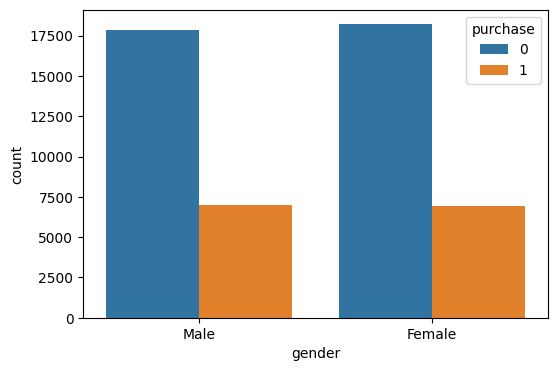

In [177]:
gender_df = df['gender'].value_counts()
print(gender_df)
plt.figure(figsize=(6,4))
sns.countplot(x= 'gender', hue= 'purchase', data= df)
plt.show()

country
India        17608
USA          12441
UK            5106
Australia     4977
Canada        4949
Germany       4919
Name: count, dtype: int64


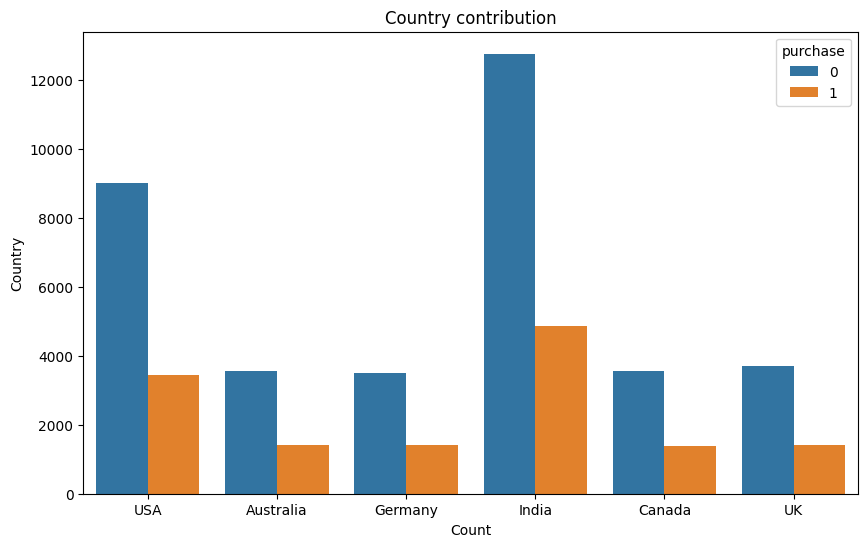

In [178]:
country_count = df['country'].value_counts()
print(country_count)
plt.figure(figsize=(10,6))
sns.countplot(x='country', hue='purchase',data=df)
plt.xlabel("Count")
plt.ylabel("Country")
plt.title("Country contribution")
plt.show()

In [179]:
Country = ['India', 'USA', 'UK', 'Australia', 'Canada', 'Germany']
for i in Country:
    df_country = df[df['country'] == i]
    df_city_count = df_country['city'].value_counts()
    print(f"============={i}============= \n{df_city_count}")
    # plt.figure(figsize=(8,6))
    # sns.countplot(data=df_city_count)
    # plt.show() 

=============India============= 
city
Bangalore    4475
Mumbai       4415
Chennai      4403
Delhi        4315
Name: count, dtype: int64
=============USA============= 
city
San Francisco    4191
New York         4126
Chicago          4124
Name: count, dtype: int64
=============UK============= 
city
Manchester    2558
London        2548
Name: count, dtype: int64
=============Australia============= 
city
Melbourne    2506
Sydney       2471
Name: count, dtype: int64
=============Canada============= 
city
Vancouver    2481
Toronto      2468
Name: count, dtype: int64
=============Germany============= 
city
Berlin    2565
Munich    2354
Name: count, dtype: int64


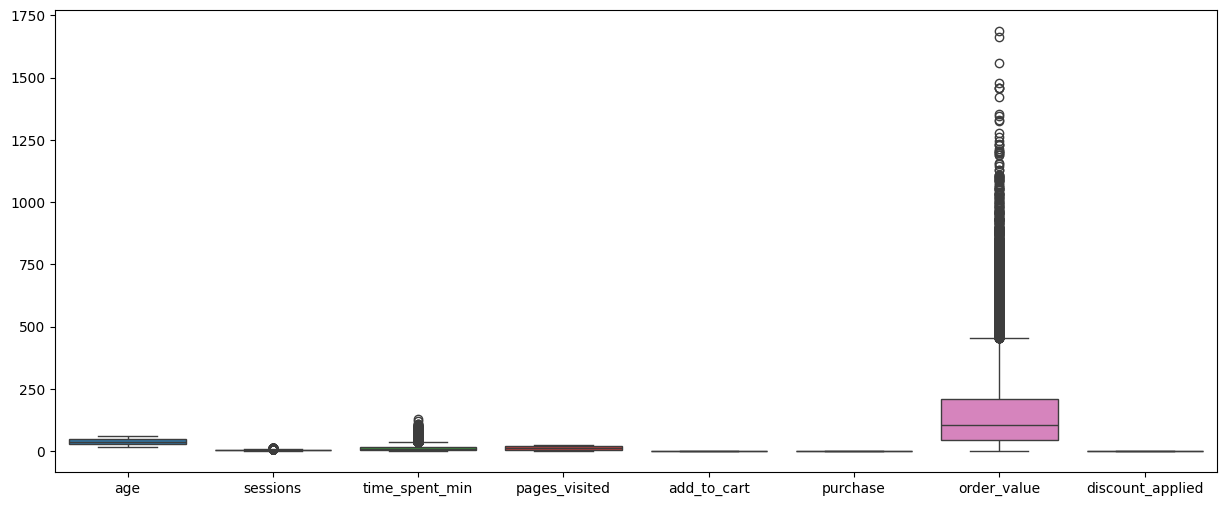

In [180]:
plt.figure(figsize=(15,6))
sns.boxplot(data= df.drop(columns='user_id'))
plt.show()

In [181]:
df = df.drop('user_id', axis=1)

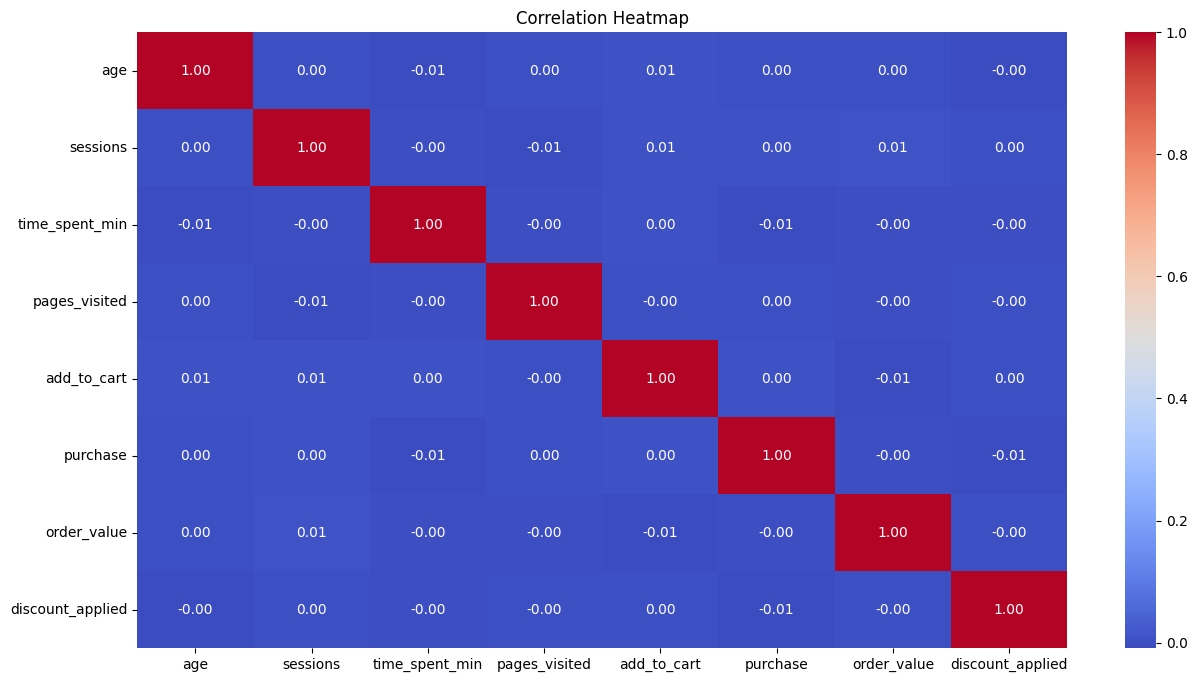

In [182]:
plt.figure(figsize=(15,8))
sns.heatmap(data=df.corr(numeric_only= True), annot=True, cmap= 'coolwarm', fmt= '.2f')
plt.title("Correlation Heatmap")
plt.show()

In [183]:
df['pages_per_session'] = df['pages_visited'] / (df['sessions'] + 1)
df['time_per_session'] = df['time_spent_min'] / (df['sessions'] + 1)
df['time_per_page'] = df['time_spent_min'] / (df['pages_visited'] + 1)
df.loc[(df['add_to_cart'] == 0) & (df['discount_applied']==0),'order_value'] = 0
df = df.drop(columns=['pages_visited', 'time_spent_min','sessions','order_value_counts', 'age_group'])

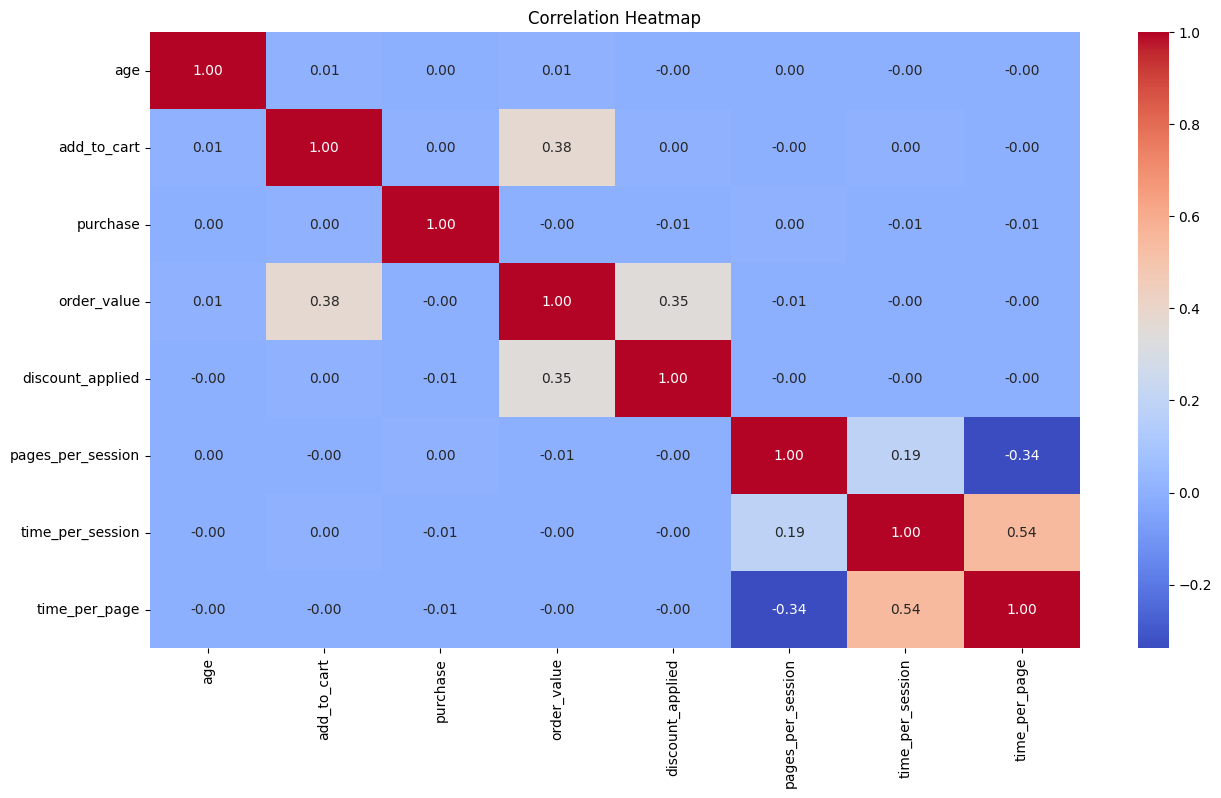

In [184]:
plt.figure(figsize=(15,8))
sns.heatmap(data=df.corr(numeric_only= True), annot=True, cmap= 'coolwarm', fmt= '.2f')
plt.title("Correlation Heatmap")
plt.show()

In [185]:
print(df.columns)
print(df.shape)

Index(['age', 'gender', 'country', 'city', 'device_type', 'traffic_source',
       'add_to_cart', 'purchase', 'order_value', 'discount_applied',
       'customer_type', 'pages_per_session', 'time_per_session',
       'time_per_page'],
      dtype='object')
(50000, 14)


In [186]:
numeric_col = ['age', 'order_value','pages_per_session', 'time_per_session', 'time_per_page']
categorical_col = ['gender', 'country', 'city', 'device_type','traffic_source','customer_type']
binary_col = ['add_to_cart', 'discount_applied']

In [187]:
numeric_col_pipeline = Pipeline([('imputer', SimpleImputer(strategy= 'median')),('scaler', StandardScaler())])
categorical_col_pipeline = Pipeline([('imputer', SimpleImputer(strategy= 'most_frequent')),('encoder', OneHotEncoder(handle_unknown= 'ignore'))])
binary_col_pipeline = Pipeline([('imputer', SimpleImputer(strategy= 'most_frequent'))])

In [188]:
preprocessor = ColumnTransformer([('numeric', numeric_col_pipeline, numeric_col), ('categorical', categorical_col_pipeline,categorical_col), ('binary', binary_col_pipeline, binary_col)])

In [189]:
RF_Model =RandomForestClassifier(n_estimators= 300, max_depth= 5,random_state= 42, n_jobs= -1)

In [196]:
RF_Pipeline = Pipeline([('preprocessor', preprocessor), ('model', RF_Model)])

In [197]:
x = df.drop('purchase', axis=1)
y = df['purchase']

In [198]:
SKF = StratifiedKFold(n_splits=5,shuffle= True, random_state=42)

In [ ]:
# cv_auc_scores = cross_val_score(RF_Pipeline,x,y,cv=SKF,scoring='roc_auc',n_jobs=-1)

In [202]:
param = {'n_estimators': [300, 500],'max_depth': [None, 10, 20],'min_samples_split': [2, 5],'min_samples_leaf': [1, 2],'max_features': ['sqrt'],'class_weight': ['balanced']}

In [203]:
randomsearchcv = RandomizedSearchCV(estimator=RF_Pipeline,param_distributions=param,n_iter=10,scoring="roc_auc",cv=SKF,n_jobs=-1,verbose=2,random_state=42)
randomsearchcv.fit(x, y)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


ValueError: Invalid parameter 'n_estimators' for estimator Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'order_value',
                                                   'pages_per_session',
                                                   'time_per_session',
                                                   'time_per_page']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   Simple

In [ ]:
print("Best ROC-AUC Score:", randomsearchcv.best_score_)
print("Best Parameters:")
print(randomsearchcv.best_params_)
best_pipeline = randomsearchcv.best_estimator_
y_pred = best_pipeline.predict(x)
y_proba = best_pipeline.predict_proba(x)[:, 1]

In [ ]:
y_pred_cv = cross_val_predict(RF_Pipeline,x,y,cv=SKF,method="predict",n_jobs=-1)

y_proba_cv = cross_val_predict(RF_Pipeline,x,y,cv=SKF,method="predict_proba",n_jobs=-1)[:, 1]

In [ ]:
print("Classification Report:")
print(classification_report(y, y_pred))
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
roc_auc = roc_auc_score(y, y_proba)
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")


In [ ]:
print("ROC-AUC scores per fold:", cv_auc_scores)
print("Mean ROC-AUC:", cv_auc_scores.mean())

ROC-AUC scores per fold: [0.50132629 0.50678399 0.51335693 0.5040481  0.49977985]
Mean ROC-AUC: 0.5050590340552806
